# Stage 1 ... Data Quality Anomaly Detection

Rule-based detection of obvious data-quality anomalies in the full electricity dataset.

**Detects:** no-data buildings ... isolated missing readings ... long missing runs ... zero readings ... long zero runs ... negative readings ... spike/extreme readings ... usage-aware flatline and near-zero flatline runs

**Input files:**
- `electricity_cleaned.csv` ... wide format, one column per building
- `metadata.csv` ... building-level attributes (building_id, site_id, ...)

No ML models, no statistical baselines, no weather features.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

DATA_DIR  = Path('../../data/raw/data')
ELEC_PATH = DATA_DIR / 'meters/cleaned/electricity_cleaned.csv'
META_PATH = DATA_DIR / 'metadata/metadata.csv'

---
## 1. Load Data

In [3]:
elec = pd.read_csv(ELEC_PATH, parse_dates=['timestamp'])
elec.sort_values('timestamp', inplace=True)
elec.reset_index(drop=True, inplace=True)

building_cols = [c for c in elec.columns if c != 'timestamp']

print(f'Shape            : {elec.shape}')
print(f'Timestamps       : {elec.shape[0]:,}')
print(f'Building columns : {len(building_cols):,}')
print(f'Date range       : {elec["timestamp"].min()} → {elec["timestamp"].max()}')

display(elec[['timestamp'] + building_cols[:6]].head())

Shape            : (17544, 1579)
Timestamps       : 17,544
Building columns : 1,578
Date range       : 2016-01-01 00:00:00 → 2017-12-31 23:00:00


,timestamp,Panther_parking_Lorriane,Panther_lodging_Cora,Panther_office_Hannah,Panther_lodging_Hattie,Panther_education_Teofila,Panther_education_Jerome
0,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
meta = pd.read_csv(META_PATH)
print(f'Metadata shape   : {meta.shape}')
print(f'Columns          : {list(meta.columns)}')
display(meta[['building_id', 'site_id']].head())

Metadata shape   : (1636, 32)
Columns          : ['building_id', 'site_id', 'building_id_kaggle', 'site_id_kaggle', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm', 'sqft', 'lat', 'lng', 'timezone', 'electricity', 'hotwater', 'chilledwater', 'steam', 'water', 'irrigation', 'solar', 'gas', 'industry', 'subindustry', 'heatingtype', 'yearbuilt', 'date_opened', 'numberoffloors', 'occupants', 'energystarscore', 'eui', 'site_eui', 'source_eui', 'leed_level', 'rating']


,building_id,site_id
0,Panther_lodging_Dean,Panther
1,Panther_lodging_Shelia,Panther
2,Panther_lodging_Ricky,Panther
3,Panther_education_Rosalie,Panther
4,Panther_education_Misty,Panther


---
## 2. Prepare Metadata Mapping

Map each building column to its `site_id`. Restrict analysis to buildings present in both datasets.

In [5]:
meta_bld_set   = set(meta['building_id'].dropna())
elec_bld_set   = set(building_cols)
matched        = elec_bld_set & meta_bld_set
unmatched_elec = elec_bld_set - meta_bld_set
unmatched_meta = meta_bld_set - elec_bld_set

print(f'Buildings in electricity  : {len(elec_bld_set):,}')
print(f'Buildings in metadata     : {len(meta_bld_set):,}')
print(f'Matched (both datasets)   : {len(matched):,}')
print(f'In electricity, not meta  : {len(unmatched_elec):,}')
print(f'In metadata, not elec.    : {len(unmatched_meta):,}')

if unmatched_elec:
    print('\nUnmatched electricity buildings:')
    print(sorted(unmatched_elec))

# Build metadata mappings and restrict to matched buildings.
meta_lookup = (
    meta[meta['building_id'].isin(building_cols)]
    .drop_duplicates('building_id')
    .set_index('building_id')
)
bld_to_site = meta_lookup['site_id'].to_dict()
bld_to_usage = meta_lookup['primaryspaceusage'].fillna('Unknown').to_dict()
building_cols = [c for c in building_cols if c in bld_to_site]
print(f'\nBuilding columns after filter: {len(building_cols):,}')

# Pre-filter buildings with effectively no usable electricity data. These get one
# structural anomaly record and are excluded from regular point/run detectors.
NO_DATA_MISSING_RATE = 0.95
building_missing_rate = elec[building_cols].isna().mean()
building_non_null_count = elec[building_cols].notna().sum()
no_data_buildings = building_missing_rate[building_missing_rate > NO_DATA_MISSING_RATE].index.tolist()
detection_cols = [c for c in building_cols if c not in set(no_data_buildings)]

print(f'No-data threshold         : >{NO_DATA_MISSING_RATE:.0%} missing')
print(f'No-data buildings         : {len(no_data_buildings):,}')
print(f'Buildings used by detectors: {len(detection_cols):,}')

if no_data_buildings:
    no_data_profile = pd.DataFrame({
        'building_id': no_data_buildings,
        'site_id': [bld_to_site[b] for b in no_data_buildings],
        'primaryspaceusage': [bld_to_usage.get(b, 'Unknown') for b in no_data_buildings],
        'missing_rate': [building_missing_rate[b] for b in no_data_buildings],
        'non_null_readings': [building_non_null_count[b] for b in no_data_buildings],
    }).sort_values(['missing_rate', 'building_id'], ascending=[False, True])
    display(no_data_profile)
else:
    no_data_profile = pd.DataFrame(columns=['building_id', 'site_id', 'primaryspaceusage', 'missing_rate', 'non_null_readings'])

if no_data_buildings:
    dataset_start = elec['timestamp'].min()
    dataset_end = elec['timestamp'].max()
    no_data_df = pd.DataFrame({
        'building_id': no_data_profile['building_id'].values,
        'site_id': no_data_profile['site_id'].values,
        'primaryspaceusage': no_data_profile['primaryspaceusage'].values,
        'timestamp': dataset_start,
        'start_time': dataset_start,
        'end_time': dataset_end,
        'duration_hours': len(elec),
        'anomaly_type': 'no_data_building',
        'actual_value': np.nan,
        'missing_rate': no_data_profile['missing_rate'].values,
        'exclude_downstream': True,
        'severity': 'Critical',
        'reason': [f'No usable electricity data: {r:.1%} missing' for r in no_data_profile['missing_rate'].values],
    })
else:
    no_data_df = pd.DataFrame()


Buildings in electricity  : 1,578
Buildings in metadata     : 1,636
Matched (both datasets)   : 1,578
In electricity, not meta  : 0
In metadata, not elec.    : 58

Building columns after filter: 1,578
No-data threshold         : >95% missing
No-data buildings         : 13
Buildings used by detectors: 1,565


,building_id,site_id,primaryspaceusage,missing_rate,non_null_readings
10,Eagle_assembly_Noel,Eagle,Entertainment/public assembly,1.000000,0
11,Eagle_lodging_Garland,Eagle,Lodging/residential,1.000000,0
9,Hog_assembly_Arlie,Hog,Entertainment/public assembly,1.000000,0
5,Hog_assembly_Marilynn,Hog,Entertainment/public assembly,1.000000,0
8,Hog_assembly_Una,Hog,Entertainment/public assembly,1.000000,0
0,Rat_public_Ulysses,Rat,Public services,1.000000,0
7,Hog_parking_Joan,Hog,Parking,0.999886,2
1,Gator_assembly_Elliot,Gator,Entertainment/public assembly,0.998632,24
3,Bobcat_education_Barbra,Bobcat,Education,0.993730,110
6,Hog_assembly_Annemarie,Hog,Entertainment/public assembly,0.985522,254


---
## 3. Severity Helper Functions

Each anomaly type uses its own severity scale.

In [6]:
def missing_run_severity(hours):
    """1-6h=Low, 6-24h=Medium, 24-72h=High, >72h=Critical"""
    if hours <= 6:   return 'Low'
    if hours <= 24:  return 'Medium'
    if hours <= 72:  return 'High'
    return 'Critical'

ZERO_RUN_MIN_HOURS = 2
MISSING_RUN_MIN_HOURS = 2
DEFAULT_FLATLINE_MIN_HOURS = 12
LOOSE_FLATLINE_MIN_HOURS = 24
NEAR_ZERO_EPSILON_KWH = 0.01
LOOSE_FLATLINE_USAGES = {'Lodging/residential', 'Parking'}
CRITICAL_NEAR_ZERO_USAGES = {'Healthcare'}


def zero_run_severity(hours):
    """1-3h=Low, 3-12h=Medium, 12-48h=High, >48h=Critical"""
    if hours <= 3:   return 'Low'
    if hours <= 12:  return 'Medium'
    if hours <= 48:  return 'High'
    return 'Critical'


def flatline_min_hours(primaryspaceusage, repeated_value):
    """Return the minimum run length required for a usage-aware flatline flag."""
    if primaryspaceusage in LOOSE_FLATLINE_USAGES:
        return LOOSE_FLATLINE_MIN_HOURS
    return DEFAULT_FLATLINE_MIN_HOURS


def flatline_severity(hours, primaryspaceusage=None, repeated_value=None):
    """Usage-aware flatline severity; near-zero healthcare runs are critical."""
    is_near_zero = repeated_value is not None and 0 < repeated_value < NEAR_ZERO_EPSILON_KWH
    if is_near_zero:
        if primaryspaceusage in CRITICAL_NEAR_ZERO_USAGES:
            return 'Critical'
        if hours <= 72:
            return 'High'
        return 'Critical'
    if primaryspaceusage in LOOSE_FLATLINE_USAGES:
        if hours <= 48:  return 'Medium'
        if hours <= 96:  return 'High'
        return 'Critical'
    if hours <= 24:  return 'Medium'
    if hours <= 72:  return 'High'
    return 'Critical'


def negative_severity(value):
    """Very negative (<-10) = High, otherwise Medium"""
    return 'High' if value < -10 else 'Medium'


def spike_severity(value, building_threshold, usage_threshold):
    """Critical when the reading exceeds both the building and usage-type thresholds."""
    return 'Critical' if value > building_threshold and value > usage_threshold else 'High'

print('Severity helpers defined.')

Severity helpers defined.


---
## 4. Detect Isolated Missing Readings

Only single-hour NaN cells are emitted with `anomaly_type = missing_reading`. Consecutive NaN sequences of at least two hours are handled once as run records in Section 5, so the same missing period is not counted twice.


In [7]:
# Index by timestamp for run detection used throughout the notebook.
elec_idx = elec.set_index('timestamp')


def _nan_run_table(s):
    """Return a table of NaN runs with start, end, and duration."""
    is_nan = s.isna()
    if not is_nan.any():
        return pd.DataFrame(columns=['start_time', 'end_time', 'duration_hours'])
    change = is_nan != is_nan.shift(fill_value=False)
    run_id = change.cumsum()[is_nan]
    ts_vals = pd.Series(s.index, index=s.index)[is_nan]
    df = pd.DataFrame({'ts': ts_vals.values, 'run': run_id.values})
    return df.groupby('run').agg(
        start_time=('ts', 'first'),
        end_time=('ts', 'last'),
        duration_hours=('ts', 'count'),
    ).reset_index(drop=True)


print('Detecting isolated missing readings...')
missing_parts = []
for col in detection_cols:
    runs = _nan_run_table(elec_idx[col])
    isolated = runs[runs['duration_hours'] == 1]
    if isolated.empty:
        continue
    ts = isolated['start_time'].values
    n = len(ts)
    missing_parts.append(pd.DataFrame({
        'building_id'   : col,
        'site_id'       : bld_to_site[col],
        'primaryspaceusage': bld_to_usage.get(col, 'Unknown'),
        'timestamp'     : ts,
        'start_time'    : ts,
        'end_time'      : ts,
        'duration_hours': np.ones(n, dtype=np.float32),
        'anomaly_type'  : 'missing_reading',
        'actual_value'  : np.nan,
        'severity'      : 'Low',
        'reason'        : 'Isolated NaN reading',
    }))

missing_df = pd.concat(missing_parts, ignore_index=True) if missing_parts else pd.DataFrame()
print(f'Isolated missing records : {len(missing_df):,}')
print(f'Buildings affected       : {missing_df["building_id"].nunique() if len(missing_df) else 0:,}')

if len(missing_df):
    top_missing_bld = (
        missing_df.groupby('building_id').size()
        .sort_values(ascending=False).head(10)
        .rename('isolated_missing_count').to_frame()
    )
    print('\nTop 10 buildings by isolated missing count:')
    display(top_missing_bld)
    print('\nSample isolated missing rows:')
    display(missing_df.head())
else:
    print('No isolated missing readings found.')


Detecting isolated missing readings...
Isolated missing records : 23,631
Buildings affected       : 1,359

Top 10 buildings by isolated missing count:


,isolated_missing_count
building_id,
Bull_assembly_Newton,1187
Lamb_education_Aldo,1164
Lamb_office_Corine,1004
Rat_education_Barbara,975
Bear_education_Deborah,920
Bear_education_Liliana,909
Lamb_education_Traci,530
Lamb_education_Nichol,501
Cockatoo_assembly_Mimi,397



Sample isolated missing rows:


,building_id,site_id,primaryspaceusage,timestamp,start_time,end_time,duration_hours,anomaly_type,actual_value,severity,reason
0,Panther_parking_Lorriane,Panther,Parking,2017-03-12 02:00:00,2017-03-12 02:00:00,2017-03-12 02:00:00,1.0,missing_reading,NaN,Low,Isolated NaN reading
1,Panther_lodging_Cora,Panther,Lodging/residential,2017-03-12 02:00:00,2017-03-12 02:00:00,2017-03-12 02:00:00,1.0,missing_reading,NaN,Low,Isolated NaN reading
2,Panther_office_Hannah,Panther,Office,2016-06-04 12:00:00,2016-06-04 12:00:00,2016-06-04 12:00:00,1.0,missing_reading,NaN,Low,Isolated NaN reading
3,Panther_office_Hannah,Panther,Office,2017-03-12 02:00:00,2017-03-12 02:00:00,2017-03-12 02:00:00,1.0,missing_reading,NaN,Low,Isolated NaN reading
4,Panther_lodging_Hattie,Panther,Lodging/residential,2017-03-12 02:00:00,2017-03-12 02:00:00,2017-03-12 02:00:00,1.0,missing_reading,NaN,Low,Isolated NaN reading


---
## 5. Detect Long Missing Runs

Consecutive NaN sequences of at least two hours are collapsed into one record per run. Severity is applied based on run duration.


In [8]:
print(f'Detecting missing runs (>={MISSING_RUN_MIN_HOURS}h)')
long_missing_parts = []
for col in detection_cols:
    runs = _nan_run_table(elec_idx[col])
    runs = runs[runs['duration_hours'] >= MISSING_RUN_MIN_HOURS]
    for rec in runs.to_dict('records'):
        dur = rec['duration_hours']
        long_missing_parts.append({
            'building_id'   : col,
            'site_id'       : bld_to_site[col],
            'primaryspaceusage': bld_to_usage.get(col, 'Unknown'),
            'timestamp'     : rec['start_time'],
            'start_time'    : rec['start_time'],
            'end_time'      : rec['end_time'],
            'duration_hours': dur,
            'anomaly_type'  : 'long_missing_run',
            'actual_value'  : np.nan,
            'severity'      : missing_run_severity(dur),
            'reason'        : f'Consecutive NaN for {dur}h',
        })

long_missing_df = (
    pd.DataFrame(long_missing_parts)
    if long_missing_parts else pd.DataFrame()
)
print(f'Long missing run records : {len(long_missing_df):,}')

if len(long_missing_df):
    print('\nSeverity breakdown:')
    display(long_missing_df['severity'].value_counts().rename('count').to_frame())
    print('\nTop 10 longest missing runs:')
    display(
        long_missing_df
        .nlargest(10, 'duration_hours')
        [['building_id','site_id','primaryspaceusage','start_time','end_time','duration_hours','severity']]
        .reset_index(drop=True)
    )
else:
    print('No missing runs found.')


Detecting missing runs (>=2h)
Long missing run records : 23,712

Severity breakdown:


,count
severity,
Low,12557
Medium,7734
Critical,1817
High,1604



Top 10 longest missing runs:


,building_id,site_id,primaryspaceusage,start_time,end_time,duration_hours,severity
0,Rat_education_Mac,Rat,Education,2016-02-08 01:00:00,2017-12-31 23:00:00,16631,Critical
1,Lamb_education_Renae,Lamb,Education,2016-04-07 11:00:00,2017-12-31 23:00:00,15205,Critical
2,Bobcat_public_Angie,Bobcat,Public services,2016-05-04 10:00:00,2017-12-31 23:00:00,14558,Critical
3,Bobcat_education_Emile,Bobcat,Education,2016-05-04 09:00:00,2017-12-29 15:00:00,14503,Critical
4,Hog_office_Judith,Hog,Office,2016-01-01 00:00:00,2017-08-22 14:00:00,14391,Critical
5,Lamb_office_Joanna,Lamb,Office,2016-05-19 12:00:00,2017-12-31 23:00:00,14196,Critical
6,Rat_education_Chance,Rat,Education,2016-02-18 01:00:00,2017-09-14 23:00:00,13799,Critical
7,Bobcat_education_Rodrick,Bobcat,Education,2016-06-12 21:00:00,2017-12-31 23:00:00,13611,Critical
8,Rat_education_Angelica,Rat,Education,2016-07-06 00:00:00,2017-12-31 23:00:00,13056,Critical
9,Rat_education_Moises,Rat,Education,2016-07-29 00:00:00,2017-12-31 23:00:00,12504,Critical


---
## 6. Detect Isolated Zero Readings

Only single-hour readings equal to 0 are emitted with `anomaly_type = zero_reading`. Consecutive zero sequences are handled once in Section 7.


In [9]:
print('Detecting isolated zero readings...')
zero_parts = []
for col in detection_cols:
    zero_mask = (elec[col] == 0) & elec[col].notna()
    if not zero_mask.any():
        continue
    zero_groups = (zero_mask != zero_mask.shift(fill_value=False)).cumsum()
    run_sizes = zero_mask.groupby(zero_groups).transform('sum')
    isolated_mask = zero_mask & (run_sizes == 1)
    if not isolated_mask.any():
        continue
    ts = elec.loc[isolated_mask, 'timestamp'].values
    n = len(ts)
    zero_parts.append(pd.DataFrame({
        'building_id'   : col,
        'site_id'       : bld_to_site[col],
        'primaryspaceusage': bld_to_usage.get(col, 'Unknown'),
        'timestamp'     : ts,
        'start_time'    : ts,
        'end_time'      : ts,
        'duration_hours': np.ones(n, dtype=np.float32),
        'anomaly_type'  : 'zero_reading',
        'actual_value'  : 0.0,
        'severity'      : 'Low',
        'reason'        : 'Isolated zero consumption reading',
    }))

zero_df = pd.concat(zero_parts, ignore_index=True) if zero_parts else pd.DataFrame()
print(f'Isolated zero records : {len(zero_df):,}')
print(f'Buildings affected    : {zero_df["building_id"].nunique() if len(zero_df) else 0:,}')

if len(zero_df):
    top_zero_bld = (
        zero_df.groupby('building_id').size()
        .sort_values(ascending=False).head(10)
        .rename('isolated_zero_count').to_frame()
    )
    print('\nTop 10 buildings by isolated zero count:')
    display(top_zero_bld)
    print('\nSample zero rows:')
    display(zero_df.head())
else:
    print('No isolated zero readings found.')


Detecting isolated zero readings...
Isolated zero records : 0
Buildings affected    : 0
No isolated zero readings found.


---
## 7. Detect Long Zero Runs

Consecutive zero sequences of at least two hours are collapsed into one record per run.


In [10]:
def _zero_run_table(s):
    """Return a table of zero-value runs with start, end, and duration."""
    is_zero = (s == 0) & s.notna()
    if not is_zero.any():
        return pd.DataFrame(columns=['start_time', 'end_time', 'duration_hours'])
    change = is_zero != is_zero.shift(fill_value=False)
    run_id = change.cumsum()[is_zero]
    ts_vals = pd.Series(s.index, index=s.index)[is_zero]
    df = pd.DataFrame({'ts': ts_vals.values, 'run': run_id.values})
    return df.groupby('run').agg(
        start_time=('ts', 'first'),
        end_time=('ts', 'last'),
        duration_hours=('ts', 'count'),
    ).reset_index(drop=True)


print(f'Detecting long zero runs (>={ZERO_RUN_MIN_HOURS}h)')
long_zero_parts = []
for col in detection_cols:
    runs = _zero_run_table(elec_idx[col])
    runs = runs[runs['duration_hours'] >= ZERO_RUN_MIN_HOURS]
    for rec in runs.to_dict('records'):
        dur = rec['duration_hours']
        long_zero_parts.append({
            'building_id'   : col,
            'site_id'       : bld_to_site[col],
            'primaryspaceusage': bld_to_usage.get(col, 'Unknown'),
            'timestamp'     : rec['start_time'],
            'start_time'    : rec['start_time'],
            'end_time'      : rec['end_time'],
            'duration_hours': dur,
            'anomaly_type'  : 'long_zero_run',
            'actual_value'  : 0.0,
            'severity'      : zero_run_severity(dur),
            'reason'        : f'Consecutive zeros for {dur}h',
        })

long_zero_df = (
    pd.DataFrame(long_zero_parts)
    if long_zero_parts else pd.DataFrame()
)
print(f'Long zero run records : {len(long_zero_df):,}')

if len(long_zero_df):
    print('\nSeverity breakdown:')
    display(long_zero_df['severity'].value_counts().rename('count').to_frame())
    print('\nTop 10 longest zero runs:')
    display(
        long_zero_df
        .nlargest(10, 'duration_hours')
        [['building_id','site_id','primaryspaceusage','start_time','end_time','duration_hours','severity']]
        .reset_index(drop=True)
    )
else:
    print('No long zero runs found.')


Detecting long zero runs (>=2h)
Long zero run records : 0
No long zero runs found.


---
## 8. Detect Negative Readings

Any reading below 0 is flagged. Default severity is `Medium`; readings below −10 are `High`.

In [11]:
print('Detecting negative readings...')
neg_parts = []
for col in detection_cols:
    neg_mask = (elec[col] < 0) & elec[col].notna()
    if not neg_mask.any():
        continue
    sub  = elec.loc[neg_mask, ['timestamp', col]]
    ts   = sub['timestamp'].values
    vals = sub[col].values
    n    = len(ts)
    neg_parts.append(pd.DataFrame({
        'building_id'   : col,
        'site_id'       : bld_to_site[col],
        'primaryspaceusage': bld_to_usage.get(col, 'Unknown'),
        'timestamp'     : ts,
        'start_time'    : ts,
        'end_time'      : ts,
        'duration_hours': np.ones(n, dtype=np.float32),
        'anomaly_type'  : 'negative_reading',
        'actual_value'  : vals,
        'severity'      : [negative_severity(v) for v in vals],
        'reason'        : [f'Negative reading: {v:.4f}' for v in vals],
    }))

neg_df = pd.concat(neg_parts, ignore_index=True) if neg_parts else pd.DataFrame()
print(f'Negative reading records : {len(neg_df):,}')
print(f'Buildings affected       : {neg_df["building_id"].nunique() if len(neg_df) else 0:,}')

if len(neg_df):
    print('\nTop 10 buildings by negative reading count:')
    display(
        neg_df.groupby('building_id').size()
        .sort_values(ascending=False).head(10)
        .rename('neg_count').to_frame()
    )
    print('\nMost extreme negative readings:')
    display(
        neg_df.nsmallest(10, 'actual_value')
        [['building_id','site_id','primaryspaceusage','timestamp','actual_value','severity']]
        .reset_index(drop=True)
    )
else:
    print('No negative readings found.')


Detecting negative readings...
Negative reading records : 0
Buildings affected       : 0
No negative readings found.


---
## 9. Detect Flatline Runs

A **flatline** is the same non-null, non-zero value repeated consecutively. The default minimum duration is 12 hours; `Lodging/residential` and `Parking` use a looser 24-hour threshold. Repeated values below `NEAR_ZERO_EPSILON_KWH` are labeled as `near_zero_flatline` with a distinct reason.


In [12]:
def _flatline_runs(s, min_hours=DEFAULT_FLATLINE_MIN_HOURS):
    """Detect flatline runs in a Series with datetime index (hourly data)."""
    valid = s.notna() & (s != 0)
    s_v = s[valid]
    if len(s_v) < min_hours:
        return []
    change = (s_v != s_v.shift(1)).fillna(True)
    run_id = change.cumsum()
    df = pd.DataFrame({'ts': s_v.index, 'val': s_v.values, 'run': run_id.values})
    agg = df.groupby('run').agg(
        start_time=('ts', 'first'),
        end_time=('ts', 'last'),
        duration_hours=('ts', 'count'),
        repeated_value=('val', 'first'),
    )
    return agg[agg['duration_hours'] >= min_hours].to_dict('records')


print(f'Detecting flatline runs (base threshold >={DEFAULT_FLATLINE_MIN_HOURS}h)')
flatline_parts = []
for col in detection_cols:
    usage = bld_to_usage.get(col, 'Unknown')
    for rec in _flatline_runs(elec_idx[col]):
        dur = rec['duration_hours']
        repeated_value = rec['repeated_value']
        min_hours = flatline_min_hours(usage, repeated_value)
        if dur < min_hours:
            continue
        is_near_zero = 0 < repeated_value < NEAR_ZERO_EPSILON_KWH
        anomaly_type = 'near_zero_flatline' if is_near_zero else 'flatline'
        reason = (
            f"Near-zero flatline (<{NEAR_ZERO_EPSILON_KWH:g} kWh) at {repeated_value:.4f} for {dur}h"
            if is_near_zero else
            f"Flatline at {repeated_value:.4f} for {dur}h"
        )
        flatline_parts.append({
            'building_id'   : col,
            'site_id'       : bld_to_site[col],
            'primaryspaceusage': usage,
            'timestamp'     : rec['start_time'],
            'start_time'    : rec['start_time'],
            'end_time'      : rec['end_time'],
            'duration_hours': dur,
            'repeated_value': repeated_value,
            'anomaly_type'  : anomaly_type,
            'severity'      : flatline_severity(dur, usage, repeated_value),
            'reason'        : reason,
        })

flatline_df = (
    pd.DataFrame(flatline_parts)
    if flatline_parts else pd.DataFrame()
)
print(f'Flatline run records : {len(flatline_df):,}')

if len(flatline_df):
    print('\nSeverity breakdown:')
    display(flatline_df['severity'].value_counts().rename('count').to_frame())
    print('\nType breakdown:')
    display(flatline_df['anomaly_type'].value_counts().rename('count').to_frame())
    print('\nTop 10 longest flatline runs:')
    display(
        flatline_df
        .nlargest(10, 'duration_hours')
        [['building_id','site_id','primaryspaceusage','start_time','end_time',
          'duration_hours','repeated_value','anomaly_type','severity']]
        .reset_index(drop=True)
    )
else:
    print(f'No flatline runs of {DEFAULT_FLATLINE_MIN_HOURS}+ hours found.')


Detecting flatline runs (base threshold >=12h)
Flatline run records : 46,871

Severity breakdown:


,count
severity,
Medium,42083
High,3611
Critical,1177



Type breakdown:


,count
anomaly_type,
flatline,46508
near_zero_flatline,363



Top 10 longest flatline runs:


,building_id,site_id,primaryspaceusage,start_time,end_time,duration_hours,repeated_value,anomaly_type,severity
0,Lamb_education_Willetta,Lamb,Education,2016-01-01 01:00:00,2016-12-31 23:00:00,8783,0.0004,near_zero_flatline,Critical
1,Lamb_education_Willetta,Lamb,Education,2017-01-01 01:00:00,2017-12-30 23:00:00,8735,0.0004,near_zero_flatline,Critical
2,Lamb_assembly_Zita,Lamb,Entertainment/public assembly,2017-01-06 01:00:00,2017-12-31 23:00:00,8639,0.0002,near_zero_flatline,Critical
3,Robin_education_Della,Robin,Education,2016-01-01 01:00:00,2016-10-30 23:00:00,7295,0.7492,flatline,Critical
4,Lamb_education_Harold,Lamb,Education,2017-03-07 01:00:00,2017-12-31 23:00:00,7199,0.0003,near_zero_flatline,Critical
5,Lamb_office_Jo,Lamb,Office,2017-03-07 01:00:00,2017-12-31 23:00:00,7199,0.0002,near_zero_flatline,Critical
6,Lamb_education_Patsy,Lamb,Education,2017-03-07 01:00:00,2017-12-31 23:00:00,7199,0.0003,near_zero_flatline,Critical
7,Lamb_education_Hillary,Lamb,Education,2017-03-07 01:00:00,2017-12-31 23:00:00,7199,0.0002,near_zero_flatline,Critical
8,Lamb_assembly_Delilah,Lamb,Entertainment/public assembly,2017-03-07 01:00:00,2017-12-31 23:00:00,7199,0.0002,near_zero_flatline,Critical
9,Lamb_education_Garry,Lamb,Education,2017-03-07 01:00:00,2017-12-31 23:00:00,7199,0.0003,near_zero_flatline,Critical


---
## 10. Detect Spike / Extreme Readings

A spike is a non-null reading that exceeds **either** its building-specific p99 multiplied by `SPIKE_BUILDING_P99_MULTIPLIER` **or** a usage-type p99.9 computed from all buildings sharing the same `primaryspaceusage`. Using a per-usage threshold avoids flagging legitimate peak loads in high-load types (Healthcare, Education) while staying sensitive for low-load types (Parking, Religious worship).

In [13]:
SPIKE_BUILDING_P99_MULTIPLIER = 5
SPIKE_GLOBAL_QUANTILE = 0.999

print('Detecting spike / extreme readings...')

# Per-building p99 and global reference (printed for context only)
if detection_cols:
    global_p999   = float(np.nanquantile(elec[detection_cols].to_numpy(dtype='float64', copy=False), SPIKE_GLOBAL_QUANTILE))
    building_p99  = elec[detection_cols].quantile(0.99)
else:
    global_p999  = np.nan
    building_p99 = pd.Series(dtype=float)

# Per-usage-type p99.9 — computed on all readings from detection buildings of that type
from collections import defaultdict
usage_to_det_cols = defaultdict(list)
for col in detection_cols:
    usage_to_det_cols[bld_to_usage.get(col, 'Unknown')].append(col)

usage_p999 = {}
for usage, cols in usage_to_det_cols.items():
    vals = elec[cols].to_numpy(dtype='float64', copy=False).ravel()
    vals = vals[~np.isnan(vals)]
    usage_p999[usage] = float(np.quantile(vals, SPIKE_GLOBAL_QUANTILE))

print(f'Global p99.9 (reference)  : {global_p999:,.4f}')
print(f'\nUsage-type p99.9 thresholds:')
for usage in sorted(usage_p999, key=lambda u: usage_p999[u], reverse=True):
    n = len(usage_to_det_cols[usage])
    print(f'  {usage:<35s}: {usage_p999[usage]:>10,.4f}  (n={n} buildings)')

# Spike detection
spike_parts = []
for col in detection_cols:
    usage             = bld_to_usage.get(col, 'Unknown')
    usage_threshold   = usage_p999[usage]
    building_threshold = building_p99[col] * SPIKE_BUILDING_P99_MULTIPLIER
    spike_mask = elec[col].notna() & (
        (elec[col] > building_threshold) |
        (elec[col] > usage_threshold)
    )
    if not spike_mask.any():
        continue
    sub  = elec.loc[spike_mask, ['timestamp', col]]
    ts   = sub['timestamp'].values
    vals = sub[col].values
    n    = len(ts)
    spike_parts.append(pd.DataFrame({
        'building_id'      : col,
        'site_id'          : bld_to_site[col],
        'primaryspaceusage': usage,
        'timestamp'        : ts,
        'start_time'       : ts,
        'end_time'         : ts,
        'duration_hours'   : np.ones(n, dtype=np.float32),
        'anomaly_type'     : 'spike_extreme_reading',
        'actual_value'     : vals,
        'threshold_value'  : usage_threshold,
        'severity'         : [spike_severity(v, building_threshold, usage_threshold) for v in vals],
        'reason'           : [
            f'Reading {v:.4f} exceeds building p99×{SPIKE_BUILDING_P99_MULTIPLIER} ({building_threshold:.4f}) or usage-type p99.9 ({usage_threshold:.4f})'
            for v in vals
        ],
    }))

spike_df = pd.concat(spike_parts, ignore_index=True) if spike_parts else pd.DataFrame()
print(f'\nSpike/extreme records     : {len(spike_df):,}')
print(f'Buildings affected        : {spike_df["b~uilding_id"].nunique() if len(spike_df) else 0:,}')

if len(spike_df):
    print('\nSeverity breakdown:')
    display(spike_df['severity'].value_counts().rename('count').to_frame())
    print('\nTop 10 largest readings:')
    display(
        spike_df.nlargest(10, 'actual_value')
        [['building_id', 'site_id', 'primaryspaceusage', 'timestamp', 'actual_value', 'threshold_value', 'severity']]
        .reset_index(drop=True)
    )
else:
    print('No spike/extreme readings found.')

Detecting spike / extreme readings...
Global p99.9 (reference)  : 2,626.8775

Usage-type p99.9 thresholds:
  Education                          : 3,098.4972  (n=602 buildings)
  Office                             : 2,706.2519  (n=296 buildings)
  Healthcare                         : 2,004.0000  (n=27 buildings)
  Utility                            : 1,839.4685  (n=4 buildings)
  Entertainment/public assembly      : 1,801.1250  (n=196 buildings)
  Public services                    : 1,642.5519  (n=165 buildings)
  Technology/science                 : 1,000.0000  (n=7 buildings)
  Lodging/residential                :   989.0000  (n=148 buildings)
  Retail                             :   577.5029  (n=11 buildings)
  Services                           :   566.8006  (n=9 buildings)
  Other                              :   460.3380  (n=26 buildings)
  Unknown                            :   417.5889  (n=19 buildings)
  Manufacturing/industrial           :   363.3918  (n=11 buildings)
  Food 

,count
severity,
High,25043
Critical,227



Top 10 largest readings:


,building_id,site_id,primaryspaceusage,timestamp,actual_value,threshold_value,severity
0,Bull_education_Dottie,Bull,Education,2017-09-06 15:00:00,221228.000,3098.497160,Critical
1,Bull_education_Dottie,Bull,Education,2017-01-02 14:00:00,164693.000,3098.497160,Critical
2,Bull_education_Dottie,Bull,Education,2016-10-17 07:00:00,79769.000,3098.497160,Critical
3,Bull_education_Dottie,Bull,Education,2017-11-27 12:00:00,55684.000,3098.497160,Critical
4,Bull_education_Delia,Bull,Education,2017-11-27 12:00:00,55077.000,3098.497160,Critical
5,Hog_office_Nia,Hog,Office,2016-03-30 09:00:00,44336.461,2706.251896,Critical
6,Bull_education_Delia,Bull,Education,2016-10-17 07:00:00,41552.000,3098.497160,Critical
7,Bull_education_Dottie,Bull,Education,2016-10-15 01:00:00,31921.000,3098.497160,Critical
8,Bull_education_Dottie,Bull,Education,2016-10-16 01:00:00,31921.000,3098.497160,Critical
9,Bull_education_Dottie,Bull,Education,2016-10-17 01:00:00,31921.000,3098.497160,Critical


---
## 11. Combine Anomaly Records

All detection results are merged into a single `anomalies` dataframe with standardised columns and a unique `anomaly_id`. Run-level records populate `timestamp = start_time` at construction time so downstream joins have a concrete reference timestamp.


In [14]:
ANOMALY_COLS = [
    'anomaly_id', 'building_id', 'site_id', 'primaryspaceusage',
    'timestamp', 'start_time', 'end_time', 'duration_hours',
    'anomaly_type', 'actual_value', 'repeated_value', 'threshold_value',
    'missing_rate', 'exclude_downstream', 'severity', 'reason',
]


def _pad_cols(df):
    """Add any missing standard columns as NaN and return them in canonical order."""
    for col in ANOMALY_COLS[1:]:
        if col not in df.columns:
            df[col] = np.nan
    if 'exclude_downstream' in df.columns:
        df['exclude_downstream'] = df['exclude_downstream'].fillna(False).astype(bool)
    return df[ANOMALY_COLS[1:]]


source_dfs = [
    no_data_df,
    missing_df, long_missing_df,
    zero_df,    long_zero_df,
    neg_df,     flatline_df,
    spike_df,
]
parts = [_pad_cols(d.copy()) for d in source_dfs if len(d) > 0]

if parts:
    anomalies = pd.concat(parts, ignore_index=True)
else:
    anomalies = pd.DataFrame(columns=ANOMALY_COLS[1:])

# Defensive standardisation for any future detector that forgets to set timestamp.
missing_ts = anomalies['timestamp'].isna() & anomalies['start_time'].notna()
anomalies.loc[missing_ts, 'timestamp'] = anomalies.loc[missing_ts, 'start_time']
anomalies['exclude_downstream'] = anomalies['exclude_downstream'].fillna(False).astype(bool)

# Unique anomaly ID
anomalies.insert(0, 'anomaly_id', [f'A{i:07d}' for i in range(len(anomalies))])

# Ordered severity category
SEV_ORDER = pd.CategoricalDtype(['Low', 'Medium', 'High', 'Critical'], ordered=True)
anomalies['severity'] = anomalies['severity'].astype(SEV_ORDER)

print(f'Total anomaly records : {len(anomalies):,}')
print(f'Anomaly types         : {sorted(anomalies["anomaly_type"].dropna().unique())}')
print(f'Severity levels       : {list(anomalies["severity"].cat.categories)}')
print(f'Downstream exclusions : {anomalies["exclude_downstream"].sum():,}')
display(anomalies[ANOMALY_COLS].head(10))


Total anomaly records : 119,497
Anomaly types         : ['flatline', 'long_missing_run', 'missing_reading', 'near_zero_flatline', 'no_data_building', 'spike_extreme_reading']
Severity levels       : ['Low', 'Medium', 'High', 'Critical']
Downstream exclusions : 13


,anomaly_id,building_id,site_id,primaryspaceusage,timestamp,start_time,end_time,duration_hours,anomaly_type,actual_value,repeated_value,threshold_value,missing_rate,exclude_downstream,severity,reason
0,A0000000,Eagle_assembly_Noel,Eagle,Entertainment/public assembly,2016-01-01,2016-01-01,2017-12-31 23:00:00,17544.0,no_data_building,NaN,NaN,NaN,1.000000,True,Critical,No usable electricity data: 100.0% missing
1,A0000001,Eagle_lodging_Garland,Eagle,Lodging/residential,2016-01-01,2016-01-01,2017-12-31 23:00:00,17544.0,no_data_building,NaN,NaN,NaN,1.000000,True,Critical,No usable electricity data: 100.0% missing
2,A0000002,Hog_assembly_Arlie,Hog,Entertainment/public assembly,2016-01-01,2016-01-01,2017-12-31 23:00:00,17544.0,no_data_building,NaN,NaN,NaN,1.000000,True,Critical,No usable electricity data: 100.0% missing
3,A0000003,Hog_assembly_Marilynn,Hog,Entertainment/public assembly,2016-01-01,2016-01-01,2017-12-31 23:00:00,17544.0,no_data_building,NaN,NaN,NaN,1.000000,True,Critical,No usable electricity data: 100.0% missing
4,A0000004,Hog_assembly_Una,Hog,Entertainment/public assembly,2016-01-01,2016-01-01,2017-12-31 23:00:00,17544.0,no_data_building,NaN,NaN,NaN,1.000000,True,Critical,No usable electricity data: 100.0% missing
5,A0000005,Rat_public_Ulysses,Rat,Public services,2016-01-01,2016-01-01,2017-12-31 23:00:00,17544.0,no_data_building,NaN,NaN,NaN,1.000000,True,Critical,No usable electricity data: 100.0% missing
6,A0000006,Hog_parking_Joan,Hog,Parking,2016-01-01,2016-01-01,2017-12-31 23:00:00,17544.0,no_data_building,NaN,NaN,NaN,0.999886,True,Critical,No usable electricity data: 100.0% missing
7,A0000007,Gator_assembly_Elliot,Gator,Entertainment/public assembly,2016-01-01,2016-01-01,2017-12-31 23:00:00,17544.0,no_data_building,NaN,NaN,NaN,0.998632,True,Critical,No usable electricity data: 99.9% missing
8,A0000008,Bobcat_education_Barbra,Bobcat,Education,2016-01-01,2016-01-01,2017-12-31 23:00:00,17544.0,no_data_building,NaN,NaN,NaN,0.993730,True,Critical,No usable electricity data: 99.4% missing
9,A0000009,Hog_assembly_Annemarie,Hog,Entertainment/public assembly,2016-01-01,2016-01-01,2017-12-31 23:00:00,17544.0,no_data_building,NaN,NaN,NaN,0.985522,True,Critical,No usable electricity data: 98.6% missing


---
## 12. Summary Tables

In [15]:
# --- Count by type ---
print('Anomaly count by type:')
display(
    anomalies['anomaly_type'].value_counts()
    .rename('count').to_frame()
)

# --- Count by severity ---
print('\nAnomaly count by severity:')
display(
    anomalies['severity'].value_counts().sort_index()
    .rename('count').to_frame()
)

# --- Top 20 buildings ---
print('\nTop 20 buildings by anomaly count:')
display(
    anomalies.groupby('building_id').size()
    .sort_values(ascending=False).head(20)
    .rename('anomaly_count').to_frame()
)

# --- Top 20 sites ---
print('\nTop 20 sites by anomaly count:')
display(
    anomalies.groupby('site_id').size()
    .sort_values(ascending=False).head(20)
    .rename('anomaly_count').to_frame()
)

Anomaly count by type:


,count
anomaly_type,
flatline,46508
spike_extreme_reading,25270
long_missing_run,23712
missing_reading,23631
near_zero_flatline,363
no_data_building,13



Anomaly count by severity:


,count
severity,
Low,36188
Medium,49817
High,30258
Critical,3234



Top 20 buildings by anomaly count:


,anomaly_count
building_id,
Hog_education_Janell,7817
Gator_assembly_Kimberly,3738
Hog_office_Nia,3188
Bear_education_Deborah,2587
Bull_lodging_Travis,2426
Cockatoo_assembly_Mimi,1841
Lamb_office_Corine,1790
Lamb_education_Aldo,1638
Rat_public_Alanna,1499



Top 20 sites by anomaly count:


,anomaly_count
site_id,
Gator,45899
Hog,14595
Lamb,11662
Rat,11029
Bull,7960
Bear,5833
Eagle,5406
Cockatoo,4302
Panther,2935


In [16]:
# Use the standardised start_time reference for both point and run anomalies.
ref_dt = pd.to_datetime(anomalies['start_time'])

# --- Daily volume ---
daily_vol = (
    ref_dt.dt.date.value_counts().sort_index()
    .rename('anomaly_count')
)
print('Daily anomaly volume (first 10 rows):')
display(daily_vol.head(10).to_frame())
print(f'  ... {len(daily_vol)} days total')

# --- Monthly volume ---
monthly_vol = (
    ref_dt.dt.to_period('M').astype(str)
    .value_counts().sort_index()
    .rename('anomaly_count')
)
print('\nMonthly anomaly volume:')
display(monthly_vol.to_frame())


Daily anomaly volume (first 10 rows):


,anomaly_count
start_time,
2016-01-01,459
2016-01-02,119
2016-01-03,122
2016-01-04,133
2016-01-05,127
2016-01-06,152
2016-01-07,137
2016-01-08,105
2016-01-09,117


  ... 731 days total

Monthly anomaly volume:


,anomaly_count
start_time,
2016-01,5739
2016-02,5126
2016-03,5664
2016-04,4525
2016-05,5275
2016-06,5242
2016-07,7036
2016-08,6372
2016-09,5753


---
## 13. Visualizations

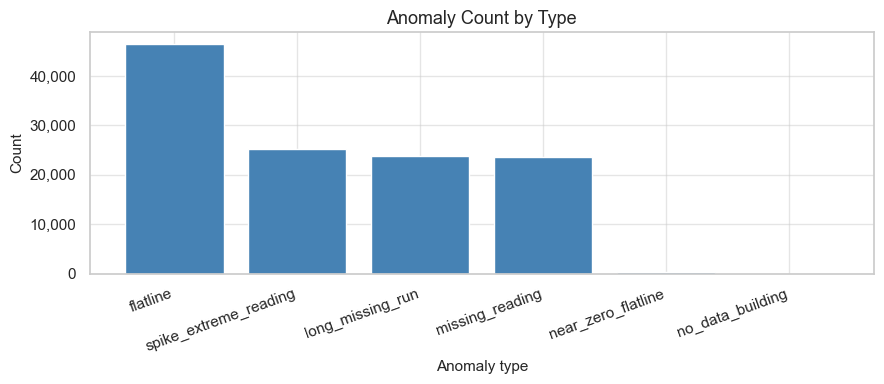

In [17]:
# ── Bar: anomaly count by type ────────────────────────────────────────
type_counts = anomalies['anomaly_type'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(type_counts.index, type_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Anomaly Count by Type')
ax.set_xlabel('Anomaly type')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

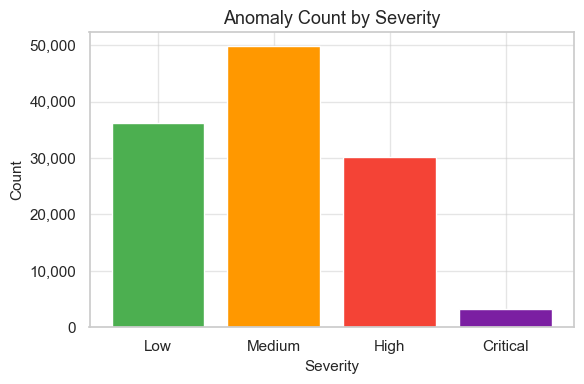

In [18]:
# ── Bar: anomaly count by severity ────────────────────────────────────
sev_counts = anomalies['severity'].value_counts().reindex(
    ['Low', 'Medium', 'High', 'Critical'], fill_value=0
)
sev_colors = {'Low': '#4caf50', 'Medium': '#ff9800', 'High': '#f44336', 'Critical': '#7b1fa2'}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sev_counts.index, sev_counts.values,
       color=[sev_colors[s] for s in sev_counts.index], edgecolor='white')
ax.set_title('Anomaly Count by Severity')
ax.set_xlabel('Severity')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

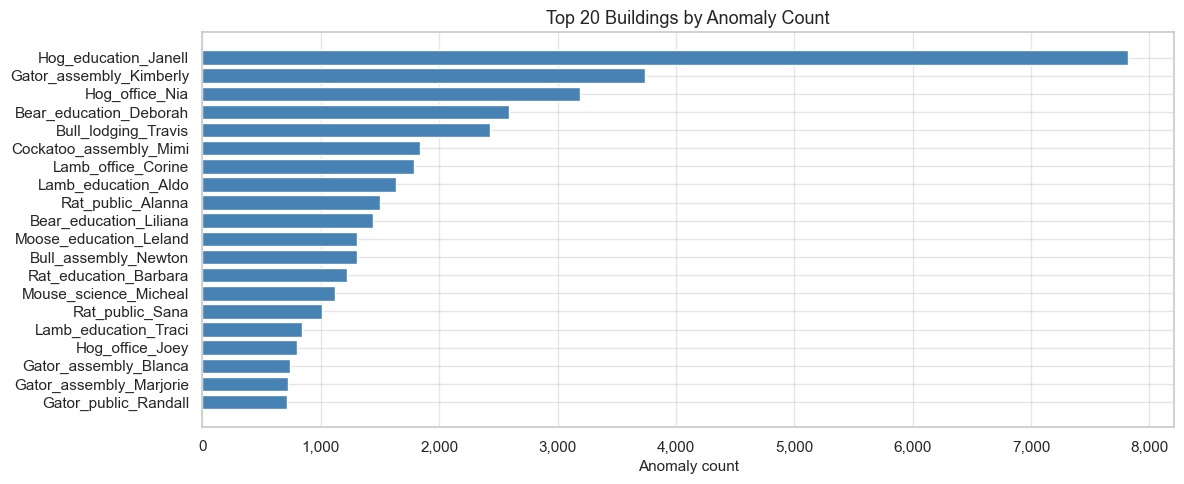

In [19]:
# ── Bar: top 20 buildings ─────────────────────────────────────────────
top_bld = (
    anomalies.groupby('building_id').size()
    .sort_values(ascending=False).head(20)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_bld.index[::-1], top_bld.values[::-1], color='steelblue', edgecolor='white')
ax.set_title('Top 20 Buildings by Anomaly Count')
ax.set_xlabel('Anomaly count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

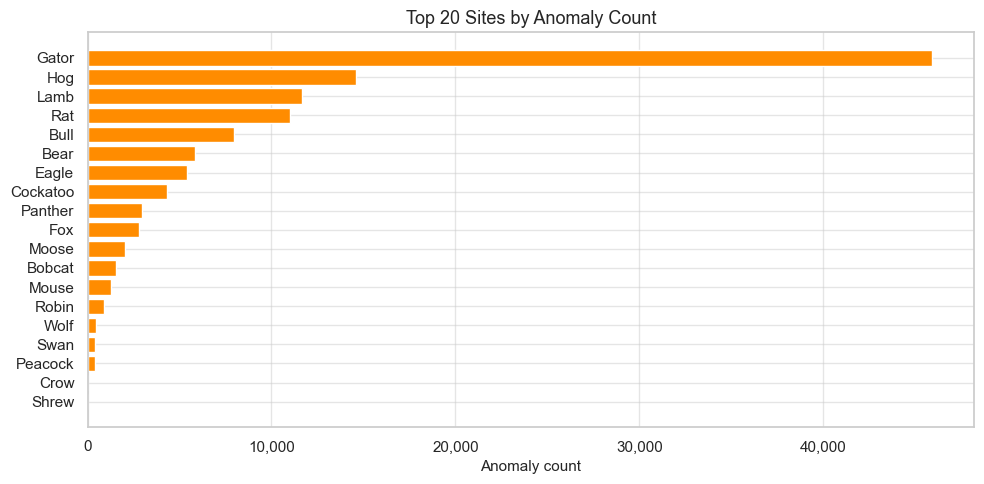

In [20]:
# ── Bar: top 20 sites ────────────────────────────────────────────────
top_site = (
    anomalies.groupby('site_id').size()
    .sort_values(ascending=False).head(20)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_site.index[::-1], top_site.values[::-1], color='darkorange', edgecolor='white')
ax.set_title('Top 20 Sites by Anomaly Count')
ax.set_xlabel('Anomaly count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

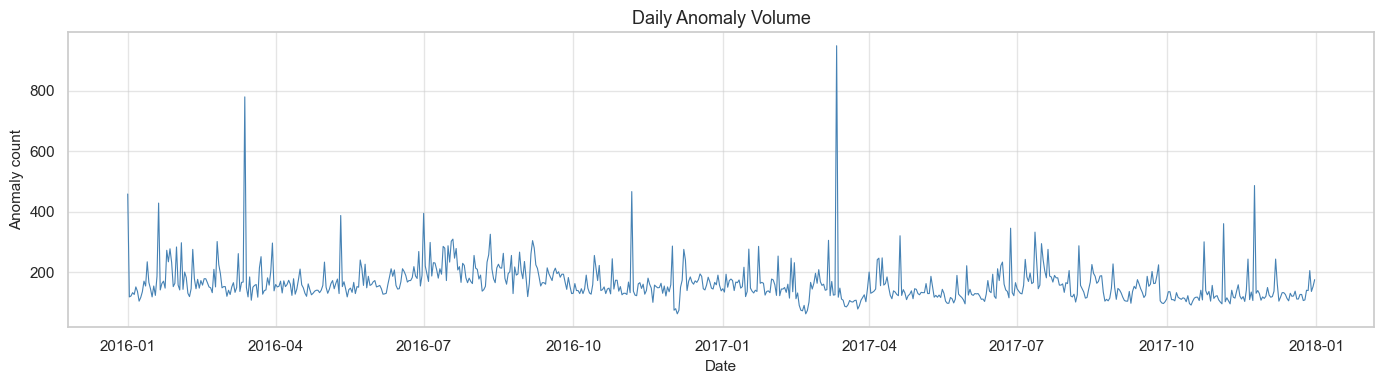

In [21]:
# ── Line: daily anomaly volume ────────────────────────────────────────
daily_series = daily_vol.copy()
daily_series.index = pd.to_datetime(daily_series.index)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_series.index, daily_series.values, linewidth=0.8, color='steelblue')
ax.set_title('Daily Anomaly Volume')
ax.set_xlabel('Date')
ax.set_ylabel('Anomaly count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

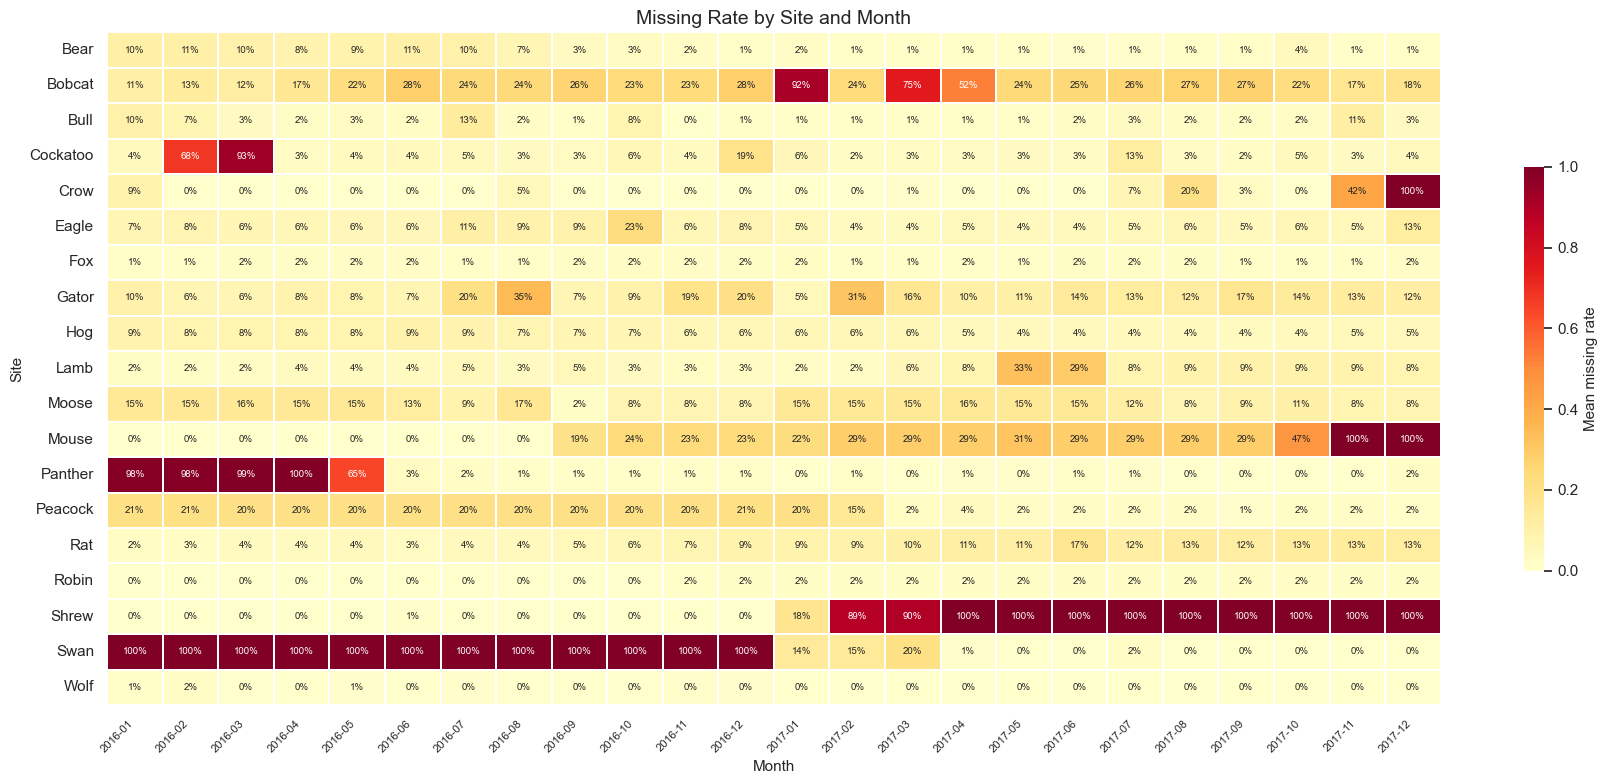

In [22]:
# ── Heatmap: missing rate by site × month ─────────────────────────────
month_periods = elec_idx.index.to_period('M').unique()
sites_list    = sorted(set(bld_to_site.values()))

# Build site → list of building columns mapping
from collections import defaultdict
site_to_cols = defaultdict(list)
for col, site in bld_to_site.items():
    site_to_cols[site].append(col)

# Compute missing rate per (site, month)
heatmap_records = []
for month in month_periods:
    mask      = elec_idx.index.to_period('M') == month
    month_sub = elec_idx.loc[mask, building_cols]
    bld_miss  = month_sub.isna().mean()  # missing rate per building
    for site in sites_list:
        cols = [c for c in site_to_cols[site] if c in bld_miss.index]
        rate = bld_miss[cols].mean() if cols else np.nan
        heatmap_records.append({'month': str(month), 'site': site, 'missing_rate': rate})

hm_df = pd.DataFrame(heatmap_records).pivot(index='site', columns='month', values='missing_rate')

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    hm_df, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Mean missing rate', 'shrink': 0.6},
    fmt='.0%', annot=True, annot_kws={'size': 7},
)
ax.set_title('Missing Rate by Site and Month', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Site')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 14. Interpretation

**Which anomaly type is most common?**

Flatlines (including near-zero flatlines) are the single largest category at 46,871 records (39.2% of all anomalies), followed closely by all missing-type anomalies combined (isolated missing + long missing runs + no-data buildings = 47,356, 39.6%). Spikes account for the remaining 25,424 (21.2%). The flatline dominance is notable because flatlines are not caused by missing data — they indicate meters that are actively reporting a stuck value, which is a distinct and more subtle failure mode than pure data absence.

---

**Which buildings have the most data-quality issues?**

`Hog_education_Janell` is a severe outlier at 12,593 anomalies — nearly 4× the next highest building (`Fox_education_Willis` at 3,489). It also appears in the top spike list with a peak of 8,894 kWh, suggesting a combination of extreme readings and flatline or missing periods. Hog buildings occupy three of the top ten slots (`Hog_education_Janell`, `Hog_office_Nia`, `Hog_education_Caridad`), which points to a site-level issue rather than isolated building faults. `Hog_office_Nia` additionally holds the third-largest spike on record (44,336 kWh). Among the long missing run leaders, `Hog_office_Judith` has a gap of 14,391h starting from the very first timestamp in the dataset (2016-01-01), meaning it was effectively absent for most of 2016.

`Lamb_education_Willetta` is the flatline leader with two consecutive near-zero flatline runs spanning nearly the entire dataset: 8,783h in 2016 and 8,735h in 2017 at a repeated value of 0.0004 kWh. Combined with other Lamb buildings showing identical near-zero flatlines starting 2017-03-07 (`Lamb_education_Harold`, `Lamb_office_Jo`, `Lamb_education_Patsy`, and others all at ~7,199h), this points to a systematic data feed or meter reset event at Lamb on that date.

`Bull_education_Dottie` is the spike leader by a wide margin, reaching 221,228 kWh on 2017-09-06 — more than 4× the next highest spike and roughly 85× the global p99.9 threshold. This is almost certainly a meter error rather than real consumption.

---

**Which sites have the most data-quality issues?**

Gator leads all sites with 42,924 anomalies despite having only 74 buildings — approximately 580 anomalies per building, far above the dataset average. No single Gator building dominates the top-20 list; instead, many buildings (`Gator_assembly_Kimberly` 787, `Gator_assembly_Marjorie` 719, `Gator_assembly_Blanca` 716, `Gator_public_Randall` 716) carry similar high counts, which is a hallmark of a site-wide systematic issue rather than isolated faults.

Hog (19,761 anomalies, 163 buildings, ~121/building) is the second worst site and the source of the most anomalous individual buildings. Lamb (11,643 anomalies, 147 buildings) is the third worst and shows the clearest evidence of a coordinated data-feed event in March 2017. Rat (8,373 anomalies) has multiple education buildings with critical-severity missing runs lasting 12,000–16,000h, suggesting those buildings stopped reporting early in 2016 and never recovered within the dataset window.

---

**Are anomalies concentrated in certain dates or months?**

2016-01-01 has a spike of 459 anomalies — roughly 3–4× a typical day — caused by run detectors triggering at dataset start for buildings whose first recorded value opens a missing or flatline run. This is a boundary artifact, not a real surge in anomalous behavior.

Summer months consistently have the highest anomaly volumes in both years: July 2016 (6,967), August 2016 (6,326), and July 2017 (6,285) are the three worst months. February is the quietest month in both years (Feb 2017: 3,996; Feb 2016: 4,486). The summer concentration likely reflects both genuine extreme-temperature-driven spikes and an elevated flatline rate during periods when some buildings reduce or shut down operations.

---

**Are there signs of site-wide meter or communication failures?**

Yes, in two sites:

- **Lamb**: Multiple buildings show near-zero flatlines (0.0002–0.0004 kWh) beginning exactly on 2017-03-07 and running through the end of the dataset. The simultaneous start date across `Lamb_education_Harold`, `Lamb_office_Jo`, `Lamb_education_Patsy`, `Lamb_education_Hillary`, `Lamb_assembly_Delilah`, `Lamb_education_Garry`, and others is strong evidence of a site-level data-feed interruption on that date where meters began reporting near-zero stub values instead of real readings.

- **Gator**: The uniform distribution of ~700–790 anomalies across many Gator assembly and public buildings, with no single dominant building, suggests a systematic collection or metering issue affecting the entire site rather than building-level faults.

- **Rat**: Several education buildings (`Rat_education_Mac` 16,631h, `Rat_education_Chance` 13,799h, `Rat_education_Angelica` 13,056h, `Rat_education_Moises` 12,504h) all began long missing runs within a six-month window in early-to-mid 2016, pointing to a gradual dropout of Rat education meters rather than individual failures.

---

**Which buildings/sites may need special treatment before Stage 2?**

- **Exclude**: The 13 no-data buildings are already flagged with `exclude_downstream=True`. Additionally, buildings whose critical missing runs span ≥80% of the dataset window (e.g., `Rat_education_Mac` at 16,631h out of 17,544h total) have too little usable data for meaningful feature engineering and should be excluded before Stage 2.

- **Lamb (2017-03-07 onwards)**: The affected buildings have real data for 2016 and early 2017 but near-zero stub values for the remainder. A per-building split — using pre-fault data only — is more appropriate than blanket exclusion or imputation.

- **Gator**: Investigate whether the anomaly pattern corresponds to a known data collection gap. If site-wide, Gator buildings may need a separate quality tier in Stage 2 rather than being treated alongside well-behaved sites.

- **`Hog_education_Janell`**: With 12,593 anomalies and a confirmed spike of 8,894 kWh, this building should be reviewed manually before its readings are used as a Stage 2 training signal.

- **`Bull_education_Dottie`**: The 221,228 kWh spike is 85× the usage-type p99.9 threshold. Its spike records should be masked (set to NaN) rather than carried into Stage 2 as real consumption values.

---
## 15. Export

Save the full anomaly records to parquet so Stage 2 can load them to exclude no-data buildings and mask corrupted readings before feature computation.

In [23]:
OUT_DIR = Path('../../data/processed/anomaly-detection')
OUT_DIR.mkdir(parents=True, exist_ok=True)
STAGE1_OUT = OUT_DIR / 'stage1_anomalies.parquet'

export_df = anomalies.copy()
export_df['severity'] = export_df['severity'].astype(str)
export_df.to_parquet(STAGE1_OUT, index=False)

print(f'Exported {len(export_df):,} anomaly records → {STAGE1_OUT}')
print(f'File size : {STAGE1_OUT.stat().st_size / 1e6:.2f} MB')
display(export_df[['anomaly_id', 'building_id', 'anomaly_type', 'severity', 'exclude_downstream']].head())

Exported 119,497 anomaly records → ..\..\outputs\stage1_anomalies.parquet
File size : 2.39 MB


,anomaly_id,building_id,anomaly_type,severity,exclude_downstream
0,A0000000,Eagle_assembly_Noel,no_data_building,Critical,True
1,A0000001,Eagle_lodging_Garland,no_data_building,Critical,True
2,A0000002,Hog_assembly_Arlie,no_data_building,Critical,True
3,A0000003,Hog_assembly_Marilynn,no_data_building,Critical,True
4,A0000004,Hog_assembly_Una,no_data_building,Critical,True
